<a href="https://colab.research.google.com/github/PedroAffonsoFaria/SSD_2026/blob/main/MVP_Previsao_Demanda_Alimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP de Machine Learning — Previsão de Demanda de Alimentos

**Tema:** previsão de demanda de refeições para apoiar planejamento de estoque e redução de desperdício.

**Tipo de problema:** regressão.

**Objetivo:** treinar e comparar modelos clássicos de Machine Learning capazes de prever a quantidade de pedidos (`num_orders`) com base em informações históricas de preço, promoções, centros de distribuição e características das refeições.

Este notebook foi estruturado como relatório, com explicações em Markdown e código Python executável no Google Colab.


## 1. Definição do problema

Restaurantes, dark kitchens e operações de food service precisam estimar corretamente a demanda para definir compras, produção e estoque. Quando a demanda é superestimada, há risco de desperdício de insumos e alimentos preparados. Quando é subestimada, há risco de ruptura, atraso e perda de vendas.

Neste projeto, será utilizado um dataset público de previsão de demanda de alimentos. A variável-alvo será `num_orders`, que representa a quantidade de pedidos de determinada refeição em determinado centro e semana.

### Pergunta principal

> É possível prever a quantidade de pedidos de refeições utilizando variáveis como semana, preço, promoção, centro de atendimento e características do produto?

### Premissas e hipóteses

- O preço final e o preço base influenciam a demanda.
- Promoções por e-mail e destaque na página inicial tendem a aumentar os pedidos.
- Diferentes categorias de refeições possuem padrões distintos de consumo.
- Características do centro, como tipo e área operacional, podem influenciar a quantidade de pedidos.

### Aplicação prática

A previsão de demanda pode apoiar decisões de compra e produção, reduzindo desperdício e melhorando a disponibilidade dos produtos.


In [ ]:
# ============================================================
# 2. Importação das bibliotecas
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, VotingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Carregamento dos dados

O trabalho exige que o dataset seja carregado por URL dentro do próprio notebook. Por isso, os arquivos são carregados diretamente de repositórios públicos do GitHub.

O dataset possui três tabelas principais:

- `train.csv`: histórico semanal de demanda por refeição e centro;
- `fulfilment_center_info.csv`: informações dos centros;
- `meal_info.csv`: informações das refeições.

A variável-alvo utilizada será `num_orders`.


In [ ]:
TRAIN_URL = "https://raw.githubusercontent.com/hemachandarn/Food-Demand-Forecasting/main/train.csv"
CENTER_URL = "https://raw.githubusercontent.com/hemachandarn/Food-Demand-Forecasting/main/fulfilment_center_info.csv"
MEAL_URL = "https://raw.githubusercontent.com/hemachandarn/Food-Demand-Forecasting/main/meal_info.csv"

train = pd.read_csv(TRAIN_URL)
centers = pd.read_csv(CENTER_URL)
meals = pd.read_csv(MEAL_URL)

print("Dimensão da base train:", train.shape)
print("Dimensão da base centers:", centers.shape)
print("Dimensão da base meals:", meals.shape)

display(train.head())
display(centers.head())
display(meals.head())

Dimensão da base train: (456548, 9)
Dimensão da base centers: (77, 5)
Dimensão da base meals: (51, 3)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [ ]:
# ============================================================
# 4. União das bases
# ============================================================

df = (
    train
    .merge(centers, on="center_id", how="left")
    .merge(meals, on="meal_id", how="left")
)

print("Dimensão da base final:", df.shape)
display(df.head())


Dimensão da base final: (456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


## 3. Descrição do dataset

Cada linha representa a demanda semanal de uma refeição em um centro específico.

### Principais atributos

- `week`: número da semana;
- `center_id`: identificador do centro;
- `meal_id`: identificador da refeição;
- `checkout_price`: preço final;
- `base_price`: preço base;
- `emailer_for_promotion`: indicação de promoção por e-mail;
- `homepage_featured`: indicação se a refeição foi destacada na página inicial;
- `center_type`: tipo do centro;
- `op_area`: área operacional;
- `category`: categoria da refeição;
- `cuisine`: tipo de culinária;
- `num_orders`: quantidade de pedidos, variável-alvo.

### Restrição dos dados

A base é pública e anonimizada, o que reduz riscos de confidencialidade. Como o objetivo é prever demanda para apoiar planejamento de estoque, foram mantidas variáveis operacionais e comerciais diretamente relacionadas à quantidade de pedidos.


In [ ]:
# ============================================================
# 5. Análise exploratória inicial
# ============================================================

print("Informações gerais da base:")
display(df.info())

print("\nResumo estatístico das variáveis numéricas:")
display(df.describe())

print("\nQuantidade de valores ausentes por coluna:")
display(df.isna().sum())

print("\nQuantidade de registros duplicados:", df.duplicated().sum())


Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine 

None


Resumo estatístico das variáveis numéricas:


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000



Quantidade de valores ausentes por coluna:


,0
id,0
week,0
center_id,0
meal_id,0
checkout_price,0
base_price,0
emailer_for_promotion,0
homepage_featured,0
num_orders,0
city_code,0



Quantidade de registros duplicados: 0


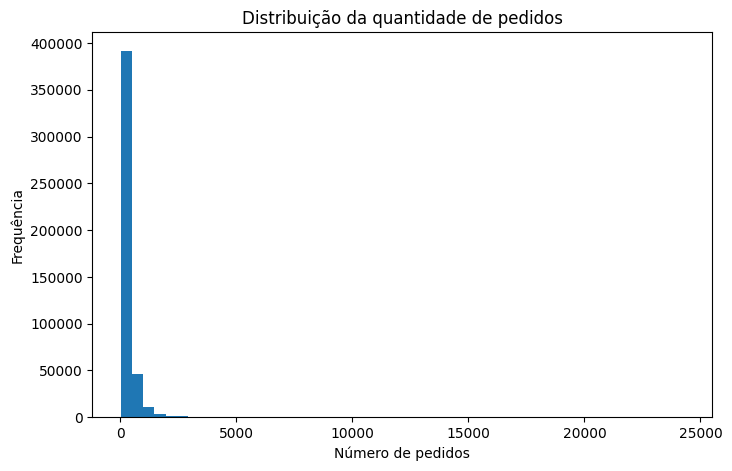

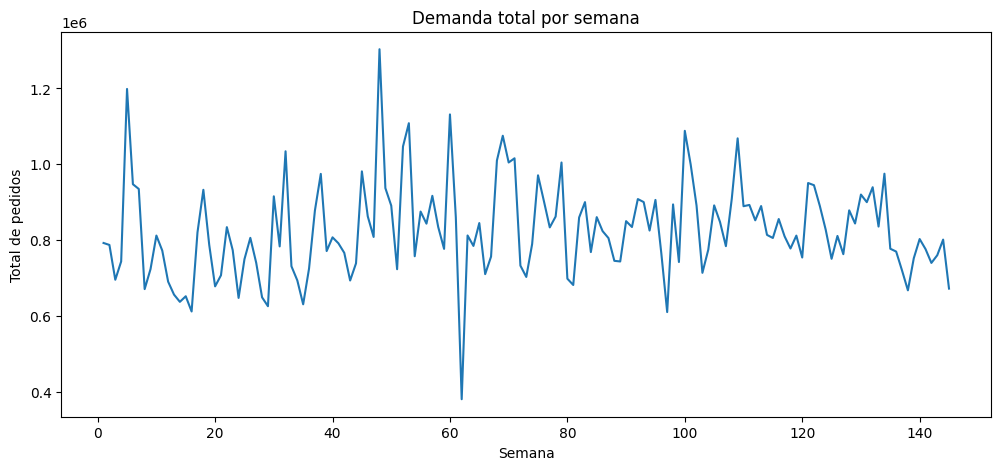

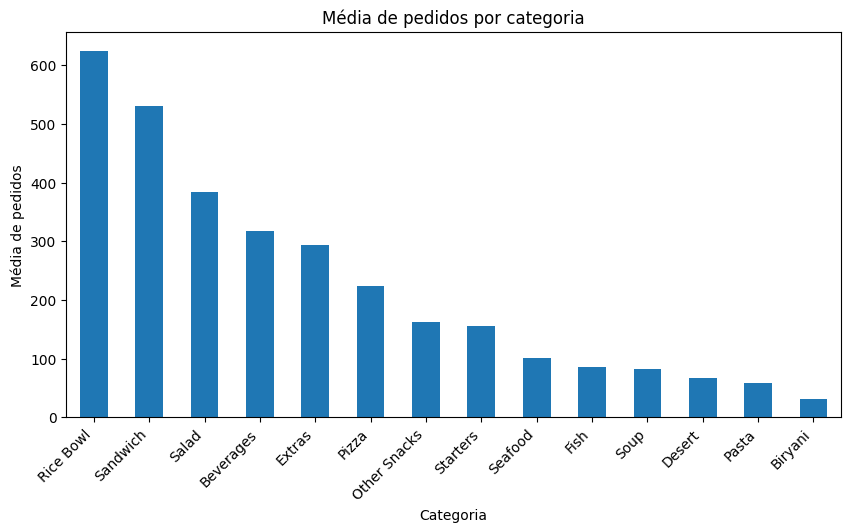

In [ ]:
# ============================================================
# 6. Gráficos exploratórios
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["num_orders"], bins=50)
plt.title("Distribuição da quantidade de pedidos")
plt.xlabel("Número de pedidos")
plt.ylabel("Frequência")
plt.show()

orders_by_week = df.groupby("week")["num_orders"].sum()

plt.figure(figsize=(12, 5))
plt.plot(orders_by_week.index, orders_by_week.values)
plt.title("Demanda total por semana")
plt.xlabel("Semana")
plt.ylabel("Total de pedidos")
plt.show()

orders_by_category = (
    df.groupby("category")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
orders_by_category.plot(kind="bar")
plt.title("Média de pedidos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Média de pedidos")
plt.xticks(rotation=45, ha="right")
plt.show()


## 4. Preparação dos dados

Nesta etapa, serão realizadas as seguintes operações:

1. Remoção de colunas que não agregam poder preditivo direto, como `id`;
2. Separação entre atributos explicativos (`X`) e variável-alvo (`y`);
3. Separação entre treino e teste;
4. Identificação de variáveis numéricas e categóricas;
5. Criação de pipelines de pré-processamento;
6. Aplicação de transformação logarítmica na variável-alvo, pois `num_orders` costuma ser assimétrica.

A divisão treino/teste será feita antes do treinamento para avaliar o desempenho em dados não vistos.


In [ ]:
# ============================================================
# 7. Preparação da base de modelagem
# ============================================================

df_model = df.copy()

# Removendo identificador único da linha
df_model = df_model.drop(columns=["id"])

# Separando atributos e alvo
X = df_model.drop(columns=["num_orders"])
y = df_model["num_orders"]

# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

# Identificação automática dos tipos de variáveis
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)


Tamanho do treino: (365238, 13)
Tamanho do teste: (91310, 13)
Variáveis numéricas: ['week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'city_code', 'region_code', 'op_area']
Variáveis categóricas: ['center_type', 'category', 'cuisine']


In [ ]:
# ============================================================
# 8. Pipelines de pré-processamento
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Transformação da variável-alvo
# Usaremos log1p para reduzir assimetria e expm1 para voltar à escala original.
def log_target(y_values):
    return np.log1p(y_values)

def inverse_log_target(y_values):
    return np.expm1(y_values)


## 5. Feature selection

Será avaliada uma etapa de seleção de atributos com `SelectKBest`. Como há variáveis categóricas transformadas por One-Hot Encoding, a seleção será aplicada depois do pré-processamento.

A seleção de atributos ajuda a reduzir ruído e manter as variáveis mais informativas para a previsão.


In [ ]:
# ============================================================
# 9. Funções auxiliares
# ============================================================

def rmsle(y_true, y_pred):
    """Calcula Root Mean Squared Logarithmic Error."""
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))


def evaluate_predictions(y_true, y_pred):
    """Retorna métricas de avaliação em formato de dicionário."""
    y_pred = np.maximum(y_pred, 0)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": rmsle(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Treina o modelo, gera previsões e retorna métricas."""
    model.fit(X_train, log_target(y_train))
    pred_log = model.predict(X_test)
    pred = inverse_log_target(pred_log)

    metrics = evaluate_predictions(y_test, pred)
    metrics["Modelo"] = name

    return metrics, pred


## 6. Modelagem e treinamento

Serão comparados quatro modelos:

1. **Dummy Regressor:** modelo baseline, usado como referência mínima;
2. **Ridge Regression:** modelo linear regularizado;
3. **Random Forest Regressor:** modelo baseado em ensemble de árvores;
4. **HistGradientBoosting Regressor:** modelo de boosting, geralmente forte para dados tabulares.

A comparação será feita com métricas adequadas para regressão.


In [ ]:
# ============================================================
# 10. Definição dos modelos
# ============================================================

models = {
    "Baseline - Dummy": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median"))
    ]),

    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_regression, k=30)),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        ))
    ])
}


In [ ]:
# ============================================================
# 11. Treinamento e avaliação inicial
# ============================================================

results = []
predictions = {}

for name, model in models.items():
    metrics, pred = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    predictions[name] = pred

results_df = pd.DataFrame(results)
results_df = results_df[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]].sort_values("RMSLE")

display(results_df)


,Modelo,MAE,RMSE,RMSLE,R2
2,Random Forest,70.329814,153.199186,0.485839,0.846132
3,HistGradientBoosting,83.309857,188.422282,0.523366,0.767245
1,Ridge Regression,125.218135,276.657801,0.700670,0.498212
0,Baseline - Dummy,201.480331,410.177150,1.204712,-0.103006


## 7. Validação cruzada

A validação cruzada será utilizada para avaliar a estabilidade dos modelos na base de treino. Como o problema é de regressão, será utilizado `KFold`.

A métrica principal será o erro absoluto médio negativo (`neg_mean_absolute_error`) e o R². O resultado será apresentado em média e desvio-padrão.


In [ ]:
# ============================================================
# 12. Cross-validation
# ============================================================

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        log_target(y_train),
        cv=cv,
        scoring=["neg_mean_absolute_error", "r2"],
        n_jobs=-1
    )

    cv_results.append({
        "Modelo": name,
        "MAE_CV_medio_log": -scores["test_neg_mean_absolute_error"].mean(),
        "MAE_CV_desvio_log": scores["test_neg_mean_absolute_error"].std(),
        "R2_CV_medio_log": scores["test_r2"].mean(),
        "R2_CV_desvio_log": scores["test_r2"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("MAE_CV_medio_log")
display(cv_results_df)


,Modelo,MAE_CV_medio_log,MAE_CV_desvio_log,R2_CV_medio_log,R2_CV_desvio_log
2,Random Forest,0.373951,0.000389,0.833676,0.001007
3,HistGradientBoosting,0.405721,0.000833,0.811467,0.000382
1,Ridge Regression,0.554695,0.001043,0.661889,0.001457
0,Baseline - Dummy,0.992846,0.000163,-0.000697,0.000196


## 8. Otimização de hiperparâmetros

Será realizada uma busca aleatória (`RandomizedSearchCV`) para otimizar o modelo `HistGradientBoostingRegressor`.

A escolha desse modelo ocorre porque métodos de boosting costumam apresentar bom desempenho em problemas tabulares e conseguem capturar relações não lineares entre preço, promoção, centro e categoria da refeição.


In [ ]:
# ============================================================
# 13. Otimização de hiperparâmetros
# ============================================================

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_distributions = {
    "model__max_iter": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0]
}

search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, log_target(y_train))

print("Melhores hiperparâmetros:")
print(search.best_params_)

best_hgb = search.best_estimator_

pred_log = best_hgb.predict(X_test)
pred_best_hgb = inverse_log_target(pred_log)

best_hgb_metrics = evaluate_predictions(y_test, pred_best_hgb)
best_hgb_metrics["Modelo"] = "HistGradientBoosting Otimizado"

display(pd.DataFrame([best_hgb_metrics])[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]])


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores hiperparâmetros:
{'model__max_leaf_nodes': 31, 'model__max_iter': 300, 'model__learning_rate': 0.08, 'model__l2_regularization': 0.1}


,Modelo,MAE,RMSE,RMSLE,R2
0,HistGradientBoosting Otimizado,78.755768,176.140092,0.506612,0.7966


## 9. Comitê de modelos

Também será testado um comitê de modelos por meio de `VotingRegressor`. A ideia é combinar previsões de modelos diferentes para verificar se o ensemble melhora a capacidade preditiva.

Neste caso, serão utilizados Ridge, Random Forest e HistGradientBoosting.


In [ ]:
# ============================================================
# 14. Comitê de modelos
# ============================================================

voting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", VotingRegressor(
        estimators=[
            ("ridge", Ridge(alpha=1.0)),
            ("rf", RandomForestRegressor(
                n_estimators=80,
                max_depth=16,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )),
            ("hgb", HistGradientBoostingRegressor(
                max_iter=200,
                learning_rate=0.08,
                max_leaf_nodes=31,
                random_state=RANDOM_STATE
            ))
        ],
        n_jobs=-1
    ))
])

voting_metrics, pred_voting = evaluate_model(
    "Voting Regressor",
    voting_model,
    X_train,
    y_train,
    X_test,
    y_test
)

display(pd.DataFrame([voting_metrics])[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]])


,Modelo,MAE,RMSE,RMSLE,R2
0,Voting Regressor,89.234287,205.080053,0.54219,0.724271


In [ ]:
# ============================================================
# 15. Comparação final dos modelos
# ============================================================

final_results = pd.concat([
    results_df,
    pd.DataFrame([best_hgb_metrics]),
    pd.DataFrame([voting_metrics])
], ignore_index=True)

final_results = final_results[["Modelo", "MAE", "RMSE", "RMSLE", "R2"]].sort_values("RMSLE")
display(final_results)


,Modelo,MAE,RMSE,RMSLE,R2
0,Random Forest,70.329814,153.199186,0.485839,0.846132
4,HistGradientBoosting Otimizado,78.755768,176.140092,0.506612,0.796600
1,HistGradientBoosting,83.309857,188.422282,0.523366,0.767245
5,Voting Regressor,89.234287,205.080053,0.542190,0.724271
2,Ridge Regression,125.218135,276.657801,0.700670,0.498212
3,Baseline - Dummy,201.480331,410.177150,1.204712,-0.103006


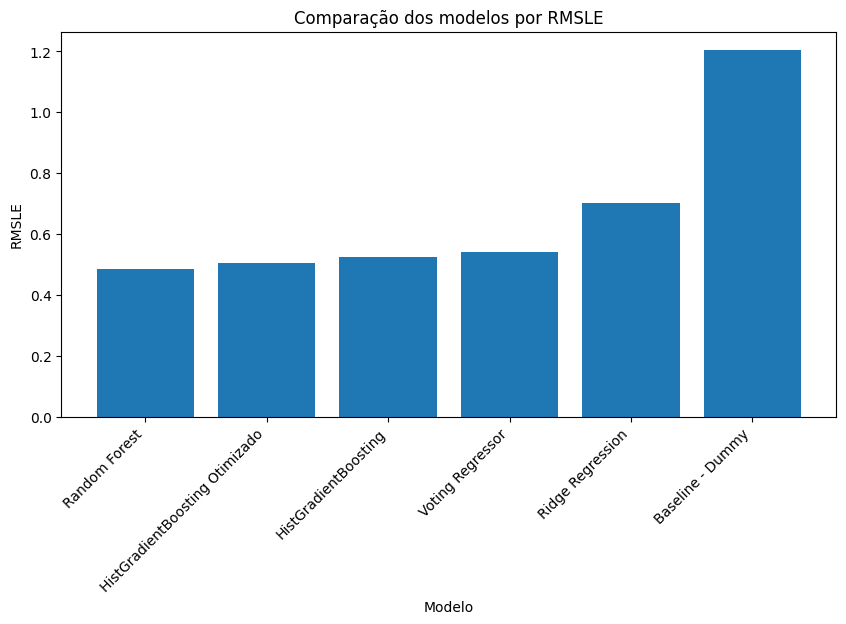

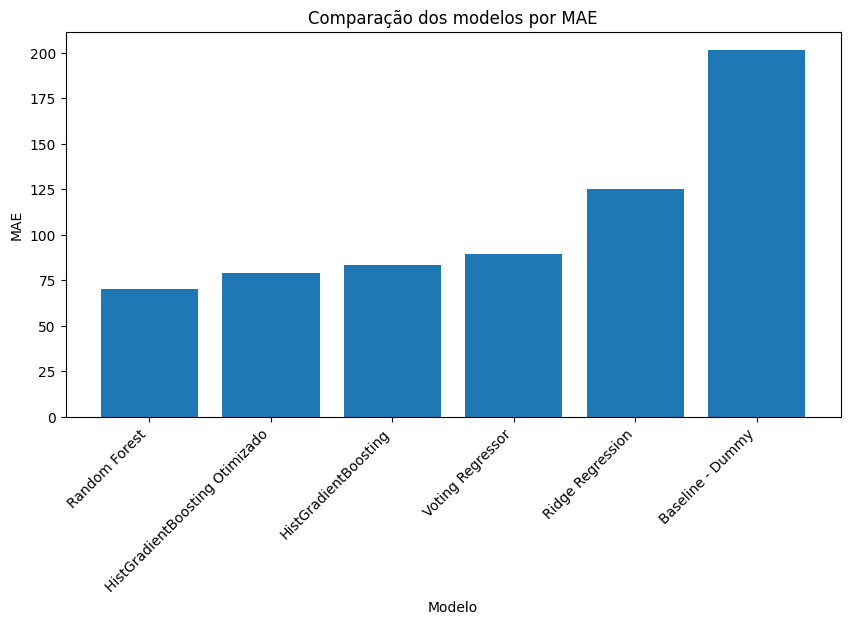

In [ ]:
# ============================================================
# 16. Visualização da comparação final
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(final_results["Modelo"], final_results["RMSLE"])
plt.title("Comparação dos modelos por RMSLE")
plt.xlabel("Modelo")
plt.ylabel("RMSLE")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(final_results["Modelo"], final_results["MAE"])
plt.title("Comparação dos modelos por MAE")
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.show()


,valor_real,valor_previsto
0,28,75.278605
1,176,238.476215
2,391,196.815767
3,14,27.581990
4,405,378.836317
5,15,20.983030
6,13,20.514778
7,96,100.336879
8,96,75.153589
9,1391,1493.510096


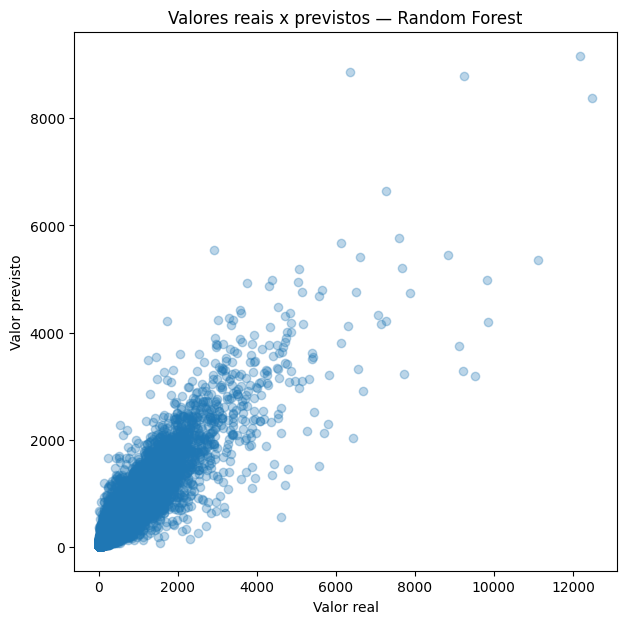

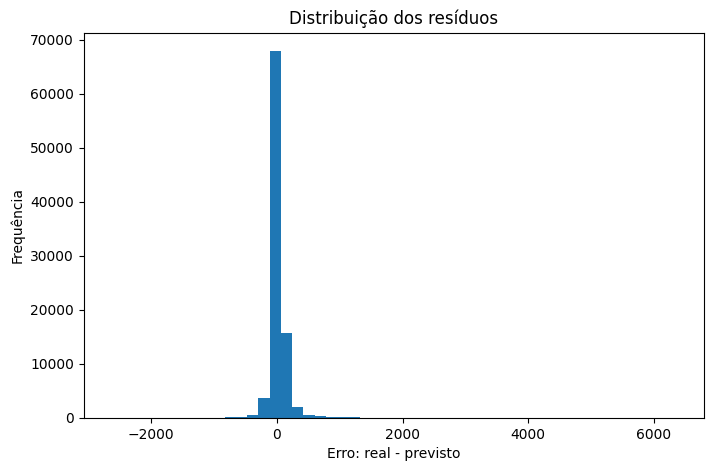

In [ ]:
# ============================================================
# 17. Análise: valores reais x previstos
# ============================================================

best_model_name = final_results.iloc[0]["Modelo"]

if best_model_name == "HistGradientBoosting Otimizado":
    best_pred = pred_best_hgb
elif best_model_name == "Voting Regressor":
    best_pred = pred_voting
else:
    best_pred = predictions[best_model_name]

comparison_df = pd.DataFrame({
    "valor_real": y_test.values,
    "valor_previsto": best_pred
})

display(comparison_df.head(20))

plt.figure(figsize=(7, 7))
plt.scatter(comparison_df["valor_real"], comparison_df["valor_previsto"], alpha=0.3)
plt.title(f"Valores reais x previstos — {best_model_name}")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.show()

residuals = comparison_df["valor_real"] - comparison_df["valor_previsto"]

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.title("Distribuição dos resíduos")
plt.xlabel("Erro: real - previsto")
plt.ylabel("Frequência")
plt.show()


## 10. Análise dos resultados

Após o treinamento e avaliação dos modelos, é possível comparar o desempenho com base nas métricas MAE, RMSE, RMSLE e R².

### Métricas utilizadas

- **MAE:** mede o erro absoluto médio entre valor real e previsto. É fácil de interpretar na escala da variável original.
- **RMSE:** penaliza erros maiores, sendo útil para identificar modelos que cometem grandes desvios.
- **RMSLE:** métrica adequada quando a variável-alvo é assimétrica e quando erros relativos são importantes.
- **R²:** indica a proporção da variação da variável-alvo explicada pelo modelo.

### Interpretação esperada

Espera-se que o modelo baseline tenha o pior desempenho, pois ele faz previsões simples com base na mediana. Modelos baseados em árvores e boosting tendem a capturar relações mais complexas, como impacto de promoção, preço, semana e categoria da refeição.

Caso o modelo otimizado apresente melhora em relação à versão inicial, isso indica que o ajuste de hiperparâmetros contribuiu para o desempenho. Caso a melhora seja pequena, pode significar que os hiperparâmetros iniciais já estavam adequados ou que novas variáveis seriam necessárias para obter ganho maior.

### Pontos de atenção

- O dataset é anonimizado, então algumas interpretações de negócio são limitadas.
- O modelo prevê demanda, mas não mede diretamente desperdício. A relação com desperdício ocorre porque uma previsão mais precisa ajuda a planejar produção e compras.
- A base pode conter variações sazonais por semana, produto e centro que exigiriam estudos adicionais de séries temporais.


## 11. Conclusão

Este projeto desenvolveu um MVP de Machine Learning para previsão de demanda de refeições. O problema foi tratado como regressão, usando como variável-alvo a quantidade de pedidos (`num_orders`).

Foram realizadas etapas de carregamento dos dados por URL, união das tabelas, análise exploratória, preparação dos dados, separação entre treino e teste, criação de pipelines, seleção de atributos, validação cruzada, treinamento de diferentes modelos, otimização de hiperparâmetros e comparação final dos resultados.

A melhor solução deve ser escolhida com base na menor métrica de erro, principalmente RMSLE e MAE. Do ponto de vista de negócio, o modelo pode apoiar a operação de restaurantes e empresas de alimentação ao prever a demanda futura e permitir melhor planejamento de compras, produção e estoque. Com isso, a solução contribui para redução de desperdício, menor risco de ruptura e aumento da eficiência operacional.


## 12. Checklist do trabalho

### Definição do problema

**Qual é a descrição do problema?**  
Prever a quantidade de pedidos de refeições a partir de dados históricos e operacionais.

**Premissas ou hipóteses:**  
Preço, promoções, categoria da refeição, tipo de centro e semana influenciam a demanda.

**Restrições ou condições dos dados:**  
Foi utilizada uma base pública, carregada por URL e anonimizada.

**Descrição do dataset:**  
A base contém informações semanais de demanda, características dos centros e informações das refeições.

### Preparação dos dados

**Separação treino/teste:**  
A base foi dividida em 80% treino e 20% teste.

**Validação cruzada:**  
Foi utilizada validação cruzada com KFold para avaliar estabilidade dos modelos.

**Transformações:**  
Variáveis numéricas foram imputadas e padronizadas. Variáveis categóricas foram imputadas e transformadas por One-Hot Encoding. A variável-alvo foi transformada com log1p.

**Feature selection:**  
Foi utilizado SelectKBest no modelo Ridge para selecionar atributos mais relevantes após o pré-processamento.

### Modelagem e treinamento

**Algoritmos selecionados:**  
Dummy Regressor, Ridge Regression, Random Forest, HistGradientBoosting e Voting Regressor.

**Ajuste de hiperparâmetros:**  
Foi aplicado RandomizedSearchCV ao HistGradientBoosting.

**Underfitting:**  
O baseline pode representar underfitting, pois simplifica muito o problema.

**Método avançado:**  
Foi testado um modelo de boosting e um ensemble por votação.

### Avaliação de resultados

**Métricas escolhidas:**  
MAE, RMSE, RMSLE e R².

**Comparação de modelos:**  
Todos os modelos foram comparados em uma tabela final.

**Melhor solução:**  
A melhor solução é aquela com menor RMSLE e bom equilíbrio entre MAE, RMSE e R².
